In [8]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Simple NN: u(x,y) -> scalar
class Net(nn.Module):
    def __init__(self, layers=(2, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):  # hidden layers
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))  # output layer
        self.net = nn.Sequential(*net)
    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        return self.net(X)

Dirichlet problem for the Laplace equation in a disk in a polar coordinates:
$D = \{0 \le r < 1, \; -\pi < \theta < \pi\},$
$$
\begin{cases}
    \Delta u = 0 & \text{in } D \\
    u(1, \theta) = 5 & \text{ on } \partial D
\end{cases}
$$
With a solution $u(r, \theta) = 5$

In [15]:
# --- Collocation points ---
N_f = 200  # number of collocation points
r_f = torch.rand(N_f, 1)
r_f.requires_grad_()
theta_f = (torch.rand(N_f, 1) - 0.5) * 2 * math.pi  # so it is in range (-pi, pi)
theta_f.requires_grad_()
u_exact = torch.full((200, 1), 5.0)

# --- Boundary points r = 1 ---
r_bc = torch.full((50, 1), 1.0)
theta_bc = 2 * math.pi * torch.rand(50, 1) - math.pi  # so it is in range (-pi, pi)
u_bc = torch.full((50, 1), 5.0)

In [16]:
net = Net((2, 20, 50, 100, 50, 20, 1))

# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)  # SGD (Stochastic Gradient Descent) with Momentum
optimizer = optim.Adam(net.parameters(), lr=1e-3)
mse_errors = []
l2_errors = []
l2_relative_errors = []
# lrs = []

for epoch in range(6001):
    optimizer.zero_grad()

    # PDE residual
    u_f = net(r_f, theta_f)
    u_theta = torch.autograd.grad(u_f.sum(), theta_f, create_graph=True)[0]
    u_r = torch.autograd.grad(u_f.sum(), r_f ,create_graph=True)[0]

    u_theta2 = torch.autograd.grad(u_theta, theta_f, torch.ones_like(u_theta), create_graph=True)[0]
    u_rr = torch.autograd.grad(u_r, r_f, torch.ones_like(u_r), create_graph=True)[0]
    f_res = u_rr + 1 / r_f * u_r + 1/torch.pow(r_f, 2) * u_theta2
    loss_pde = torch.mean(f_res**2)

    # Boundary loss r=1
    u_bc_pred = net(r_bc, theta_bc)
    loss_bc = torch.mean((u_bc - u_bc_pred) ** 2)

    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()
    l2_errors.append(torch.norm(u_f - u_exact).detach().item())
    l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
    mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())
    # lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 65.798340
Epoch 1000, Loss: 0.134909
Epoch 2000, Loss: 0.002510
Epoch 3000, Loss: 0.000965
Epoch 4000, Loss: 0.000347
Epoch 5000, Loss: 0.000105
Epoch 6000, Loss: 0.000043


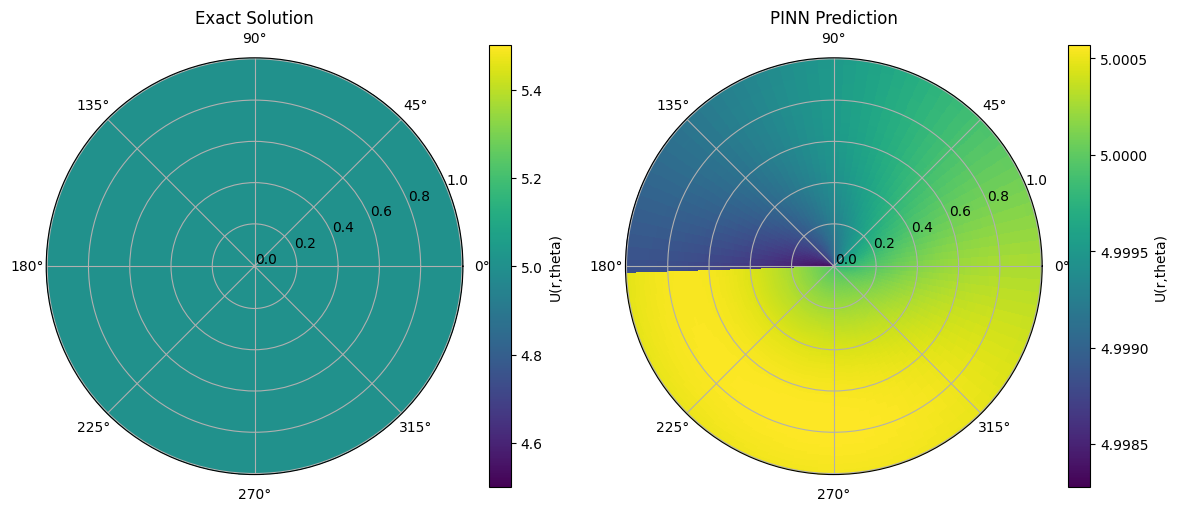

In [17]:
r_test = torch.linspace(0, 1, 100)
theta_test = torch.linspace(-math.pi, math.pi, 100)
R,Theta = torch.meshgrid(r_test, theta_test)
# (R[i,j], Theta[i,j]) is the coordinate of the (i,j) point in the 2D (r,theta) domain.
R_flat = R.reshape(-1,1)
Theta_flat = Theta.reshape(-1,1)

with torch.no_grad():
    u_pred = net(R_flat, Theta_flat).reshape(100, 100)
    u_exact = torch.full((100, 100), 5.0)

# Create 1x2 polar subplots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection':'polar'}, figsize=(12,5))

# First polar heatmap
c1 = axes[0].pcolormesh(Theta, R, u_exact, shading='auto', cmap='viridis')
fig.colorbar(c1, ax=axes[0], orientation='vertical', label='U(r,theta)')
axes[0].set_title("Exact Solution")

# Second polar heatmap
c2 = axes[1].pcolormesh(Theta, R, u_pred, shading='auto', cmap='viridis')
fig.colorbar(c2, ax=axes[1], orientation='vertical', label='U(r,theta)')
axes[1].set_title("PINN Prediction")

plt.tight_layout()
plt.show()


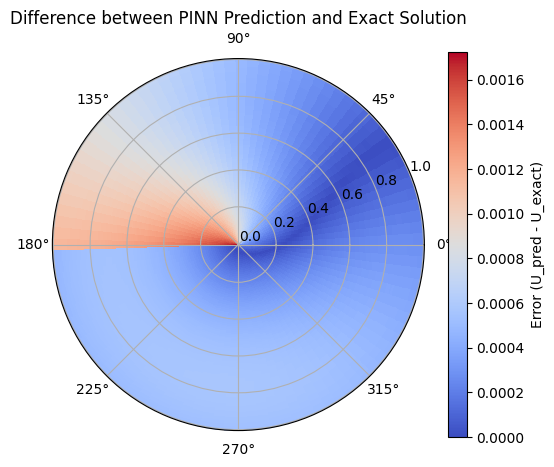

In [18]:
# Plot in a single polar subplot
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(6,5))

c = ax.pcolormesh(Theta, R, abs(u_exact - u_pred), shading='auto', cmap='coolwarm')  # coolwarm shows +/− nicely
fig.colorbar(c, ax=ax, orientation='vertical', label='Error (U_pred - U_exact)')
ax.set_title("Difference between PINN Prediction and Exact Solution")

plt.show()

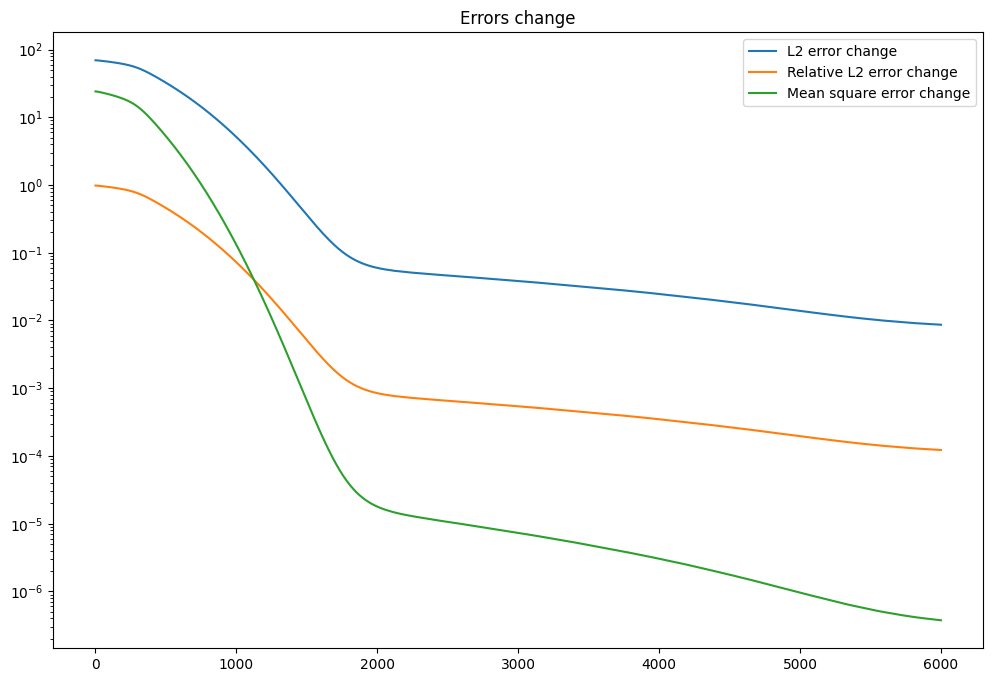

Minimum mean square error: 3.7494208982025157e-07
Minimum l2 error: 0.008659584447741508
Minimum relative l2 error: 0.00012246501773640538


In [19]:
plt.figure(figsize=(12,8))

# plt.subplot(2,1,1)
plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
plt.legend()
plt.title('Errors change')
"""
plt.subplot(2,1,2)
plt.semilogy(np.arange(0, 6001), lrs, label="L2 error change")
plt.title('Learning rate change')
"""
plt.show()
print(f"Minimum mean square error: {min(mse_errors)}")
print(f"Minimum l2 error: {min(l2_errors)}")
print(f"Minimum relative l2 error: {min(l2_relative_errors)}")